# MMLU Has Blind Spots. Here's the Topology.

Every model on the leaderboard is evaluated against [MMLU](https://arxiv.org/abs/2009.03300) as if it's a uniform test. **It isn't.**

MMLU has 57 subject categories and ~14,000 test questions. Leaderboard reporting reduces each model to a single accuracy number — or at best, four coarse category averages (STEM, Humanities, Social Sciences, Other). But what does the benchmark *actually* look like geometrically?

We ran [Pulsar](https://github.com/Krv-Labs/pulsar) — a 264-configuration topological sweep — on the full MMLU question set and found that:

1. **MMLU has distinct geometric regions** that do not align with its 57 subject labels
2. **Models perform unevenly** across these topological regions
3. **Standard leaderboard reporting hides this** by averaging across structurally different question types

This notebook reproduces the full analysis. No GPU required. No API keys.

---
## Step 1: Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Pulsar
from pulsar.config import load_config

# External deps — install hints if missing
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    raise ImportError("pip install sentence-transformers")

try:
    from datasets import load_dataset
except ImportError:
    raise ImportError("pip install datasets")

try:
    import umap
except ImportError:
    raise ImportError("pip install umap-learn")

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("All imports loaded.")

All imports loaded.


---
## Step 2: Load the MMLU Benchmark

We load all ~14,000 test questions across 57 subjects from HuggingFace.

In [2]:
MMLU_CACHE = DATA_DIR / "mmlu_questions.csv"

if MMLU_CACHE.exists():
    print(f"Loading cached MMLU from {MMLU_CACHE}")
    df_mmlu = pd.read_csv(MMLU_CACHE)
else:
    print("Downloading MMLU from HuggingFace (cais/mmlu, test split)...")
    ds = load_dataset("cais/mmlu", "all", split="test")
    df_mmlu = ds.to_pandas()
    # Convert choices list to a string for CSV storage
    df_mmlu["choices"] = df_mmlu["choices"].apply(lambda cs: "|||".join(cs))
    df_mmlu.to_csv(MMLU_CACHE, index=False)
    print(f"Saved {len(df_mmlu)} questions to {MMLU_CACHE}")

print(f"\n{len(df_mmlu):,} questions across {df_mmlu['subject'].nunique()} subjects")
print(
    f"\nSubject sizes (min/median/max): "
    f"{df_mmlu['subject'].value_counts().min()} / "
    f"{int(df_mmlu['subject'].value_counts().median())} / "
    f"{df_mmlu['subject'].value_counts().max()}"
)
df_mmlu.head(3)

Loading cached MMLU from data/mmlu_questions.csv

14,042 questions across 57 subjects

Subject sizes (min/median/max): 100 / 173 / 1534


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,0|||4|||2|||6,1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,8|||2|||24|||120,2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"0|||1|||0,1|||0,4",3


---
## Step 3: Embed the Questions

We use [BAAI/bge-small-en-v1.5](https://huggingface.co/BAAI/bge-small-en-v1.5) — a 33M-parameter model that produces 384-dimensional embeddings. Runs on CPU in ~3 minutes.

We embed **question text only** (not answer choices) to capture the semantic content of each problem without hitting the model's 512-token limit.

> **Embedding lens caveat:** All geometric structure we find downstream is conditioned on bge-small-en-v1.5's learned representation. A different embedding model might produce different cluster boundaries. As a general-purpose retrieval model not fine-tuned on MMLU or any academic domain, bge-small provides a reasonable neutral lens — but the topology we discover is real structure *in this embedding space*, not necessarily the only valid decomposition of MMLU.

In [3]:
EMBED_CACHE = DATA_DIR / "mmlu_embeddings_all.npy"

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE}")
    embeddings_all = np.load(EMBED_CACHE)
else:
    import torch

    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    print(f"Using device: {device}")

    print("Loading BAAI/bge-small-en-v1.5 (33M params, ~120MB download)...")
    encoder = SentenceTransformer("BAAI/bge-small-en-v1.5", device=device)

    texts = df_mmlu["question"].tolist()

    print(f"Encoding {len(texts):,} questions...")
    embeddings_all = encoder.encode(
        texts,
        show_progress_bar=True,
        batch_size=64,
        normalize_embeddings=True,
    )
    embeddings_all = embeddings_all.astype(np.float64)
    np.save(EMBED_CACHE, embeddings_all)
    print(f"Saved embeddings to {EMBED_CACHE}")

print(f"Embedding shape: {embeddings_all.shape}")

Loading cached embeddings from data/mmlu_embeddings_all.npy
Embedding shape: (14042, 384)


---
## Step 4: Stratified Subsample

Pulsar's cosmic graph operates on an (N x N) matrix. To keep memory comfortable on a laptop (~200MB vs 1.5GB), we take a stratified subsample of 5,000 questions — proportional to subject frequency, with a minimum of 10 per subject.

We'll propagate cluster labels back to all 14k questions later via nearest-neighbor assignment.

In [4]:
N_SUBSAMPLE = 5000

rng = np.random.default_rng(42)

# Stratified sampling: proportional to subject frequency, min 10 per subject
indices = []
for subj in df_mmlu["subject"].unique():
    subj_idx = df_mmlu.index[df_mmlu["subject"] == subj].tolist()
    n_take = max(10, int(N_SUBSAMPLE * len(subj_idx) / len(df_mmlu)))
    n_take = min(n_take, len(subj_idx))
    chosen = rng.choice(subj_idx, size=n_take, replace=False)
    indices.extend(chosen.tolist())

# Trim to exactly N_SUBSAMPLE if oversampled
if len(indices) > N_SUBSAMPLE:
    indices = sorted(rng.choice(indices, size=N_SUBSAMPLE, replace=False))
else:
    indices = sorted(indices)

embeddings_sub = embeddings_all[indices]
df_sub = df_mmlu.iloc[indices].reset_index(drop=True)

print(f"Subsample: {len(df_sub):,} questions, {df_sub['subject'].nunique()} subjects")
print(f"Embedding matrix: {embeddings_sub.shape}")

Subsample: 4,970 questions, 57 subjects
Embedding matrix: (4970, 384)


---
## Step 5: Run `Pulsar`'s Topological Sweep

Pulsar sweeps **264 parameter configurations** (3 PCA dimensions x 8 random seeds x 11 Ball Mapper radii). Each configuration produces a different topological view of the data. The **Cosmic Graph** fuses all 264 views into a single structural summary where:

- **Nodes** = questions (one per data point)
- **Edge weights** = how consistently two questions appear in the same topological neighborhood across all 264 configurations

The epsilon values are calibrated to the post-StandardScaler distance distribution at each PCA dimension — this is critical for producing diverse, informative ball maps rather than degenerate ones.

:bulb: ***Note:*** this may take 1-5 minutes to run based on your hardware.

1) Load Config `.yaml`

In [5]:
import yaml

with open("mmlu_params.yaml") as f:
    cfg = load_config(yaml.safe_load(f))

n_pca = len(cfg.pca.dimensions) * len(cfg.pca.seeds)
n_eps = len(cfg.ball_mapper.epsilons)
n_maps = n_pca * n_eps

print(
    f"Sweep: {len(cfg.pca.dimensions)} dims x {len(cfg.pca.seeds)} seeds "
    f"x {n_eps} epsilons = {n_maps} ball maps\n"
)

Sweep: 3 dims x 8 seeds x 11 epsilons = 264 ball maps



2) Run `ThemaRS`

In [6]:
from pulsar import ThemaRS

model = ThemaRS(cfg).fit(data=pd.DataFrame(embeddings_sub))
G = model.cosmic_graph

---
## Step 6: How Many Regions? Silhouette Analysis

Rather than picking an arbitrary number of clusters, we let the data decide. We run spectral clustering on the cosmic graph for k=2 through 15 and measure **silhouette score** — how well each question fits its assigned region vs. the next-best region. The peak tells us how many structurally distinct regions the cosmic graph naturally supports.

Spectral clustering uses the eigenvectors of the graph Laplacian, so the topology is doing the structural work. The silhouette score just picks the resolution.

> **Why this matters beyond MMLU:** Most real-world datasets (EHR, genomics, sensor data) have *sparser, more separated* structure than text embeddings. Pulsar's auto-threshold (persistent homology on edge weights) finds natural breakpoints with zero tuning in those cases. MMLU is a *harder* case — the embedding space is smooth and concentrated — which makes it a good stress test for Pulsar's topological machinery.

Silhouette sweep:
  k= 2  silhouette=0.0387  sizes=[np.int64(4652), np.int64(318)]
  k= 3  silhouette=0.0436  sizes=[np.int64(4087), np.int64(565), np.int64(318)]
  k= 4  silhouette=0.0482  sizes=[np.int64(3071), np.int64(1028), np.int64(553), np.int64(318)]
  k= 5  silhouette=0.0528  sizes=[np.int64(2001), np.int64(1121), np.int64(1008), np.int64(522), np.int64(318)]
  k= 6  silhouette=0.0563  sizes=[np.int64(1329), np.int64(1046), np.int64(910), np.int64(834), np.int64(533), np.int64(318)]
  k= 7  silhouette=0.0563  sizes=[np.int64(1020), np.int64(994), np.int64(883), np.int64(728), np.int64(597), np.int64(430), np.int64(318)]
  k= 8  silhouette=0.0570  sizes=[np.int64(919), np.int64(876), np.int64(844), np.int64(640), np.int64(569), np.int64(527), np.int64(318), np.int64(277)]
  k= 9  silhouette=0.0586  sizes=[np.int64(982), np.int64(892), np.int64(648), np.int64(615), np.int64(546), np.int64(363), np.int64(340), np.int64(318), np.int64(266)]
  k=10  silhouette=0.0588  sizes=[np.int

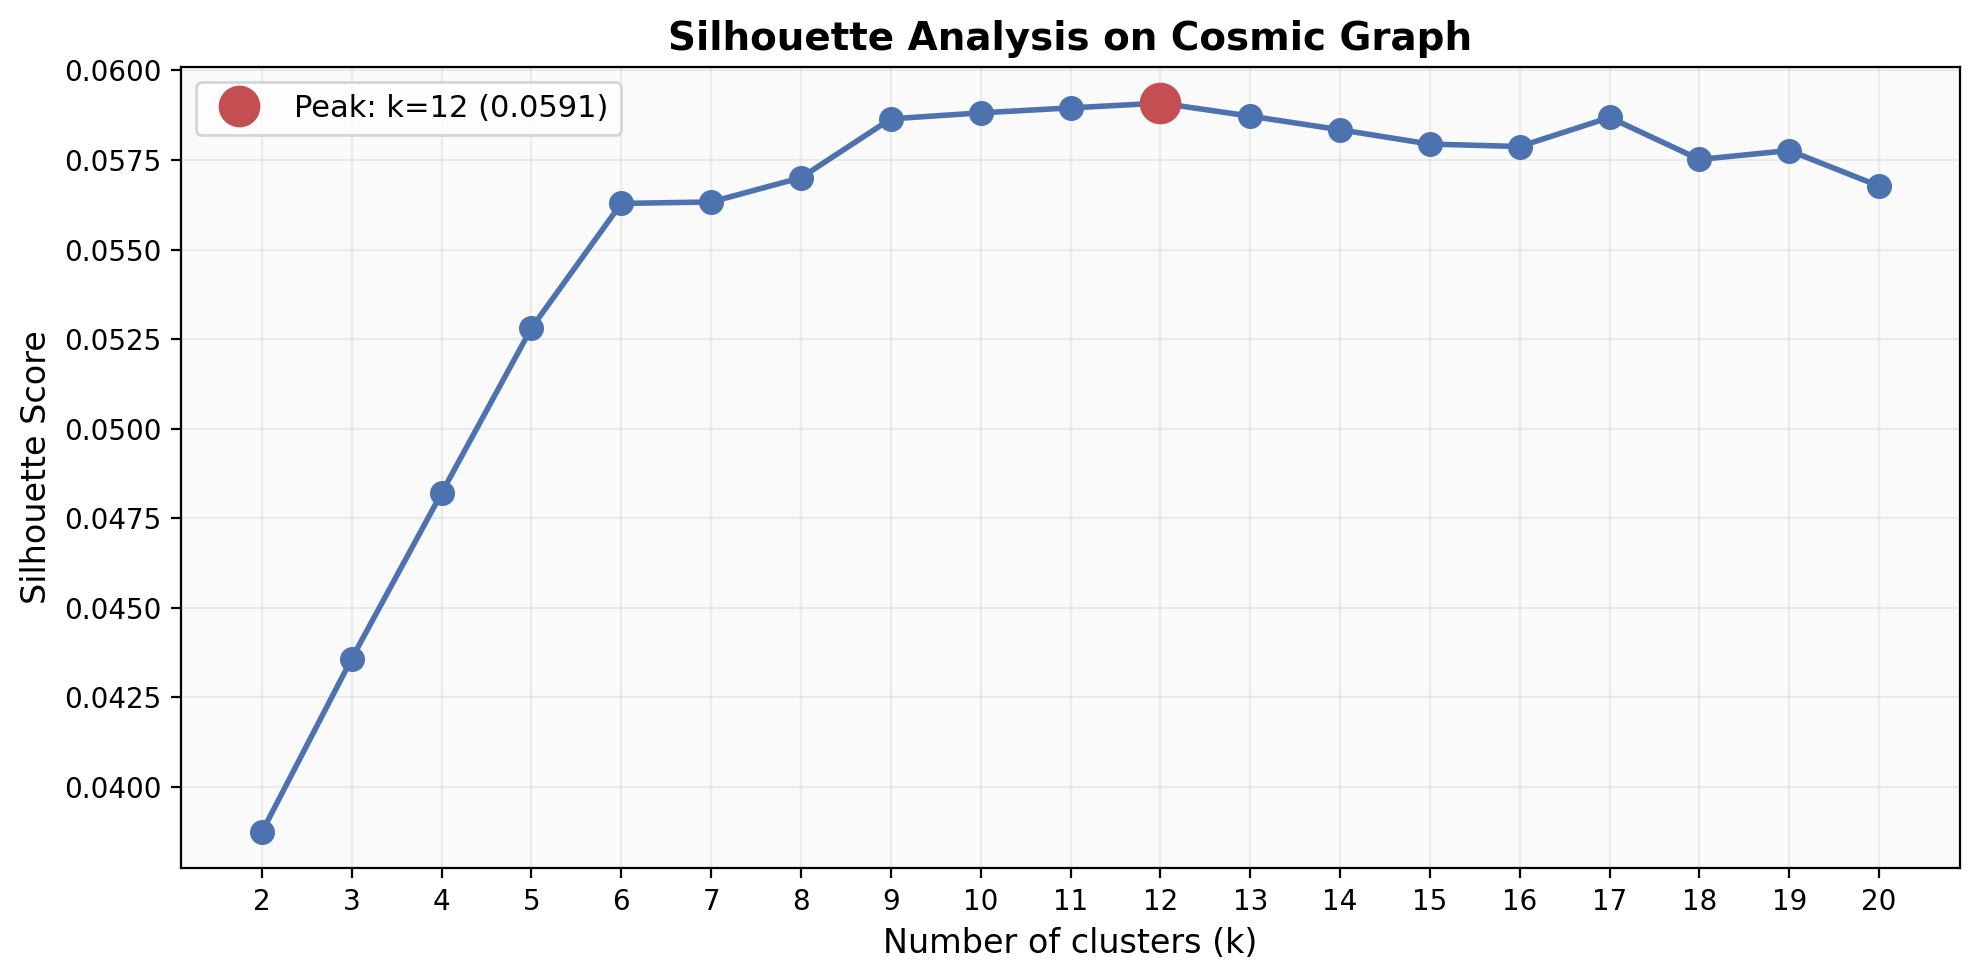


Found 12 topological regions
Region sizes: [np.int64(495), np.int64(569), np.int64(263), np.int64(483), np.int64(276), np.int64(307), np.int64(318), np.int64(610), np.int64(457), np.int64(509), np.int64(457), np.int64(226)]

--- Top 3 subjects per topological region ---

Region 0 (495 questions, spans 39 subjects):
  high_school_chemistry: 66 (13%)
  miscellaneous: 57 (12%)
  conceptual_physics: 47 (9%)

Region 1 (569 questions, spans 45 subjects):
  high_school_psychology: 61 (11%)
  professional_psychology: 58 (10%)
  high_school_statistics: 41 (7%)

Region 2 (263 questions, spans 5 subjects):
  professional_law: 255 (97%)
  professional_accounting: 3 (1%)
  professional_psychology: 3 (1%)

Region 3 (483 questions, spans 35 subjects):
  elementary_mathematics: 113 (23%)
  high_school_mathematics: 82 (17%)
  college_mathematics: 31 (6%)

Region 4 (276 questions, spans 23 subjects):
  high_school_macroeconomics: 101 (37%)
  high_school_microeconomics: 55 (20%)
  marketing: 31 (11%)

R

In [7]:
import warnings
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

W = model.weighted_adjacency

# Build distance matrix for silhouette scoring
dist_matrix = 1.0 - W
np.fill_diagonal(dist_matrix, 0.0)

# Sweep k=2..15, compute silhouette score for each
k_range = range(2, 21)
silhouette_scores = []

print("Silhouette sweep:")
for k in k_range:
    sc = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        random_state=42,
        n_init=10,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Graph is not fully connected.*",
            category=UserWarning,
        )
        cluster_labels = sc.fit_predict(W)
    score = silhouette_score(dist_matrix, cluster_labels, metric="precomputed")
    silhouette_scores.append(score)
    sizes = sorted(np.bincount(cluster_labels), reverse=True)
    print(f"  k={k:2d}  silhouette={score:.4f}  sizes={sizes}")

# Find the peak
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
N_CLUSTERS = best_k

print(f"\nPeak silhouette at k = {N_CLUSTERS} (score = {best_score:.4f})")

# Plot
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white", dpi=200)
ax.plot(
    list(k_range), silhouette_scores, "o-", color="#4C72B0", markersize=8, linewidth=2
)
ax.plot(
    N_CLUSTERS,
    best_score,
    "o",
    color="#C44E52",
    markersize=14,
    zorder=5,
    label=f"Peak: k={N_CLUSTERS} ({best_score:.4f})",
)
ax.set_xlabel("Number of clusters (k)", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Silhouette Analysis on Cosmic Graph", fontsize=14, fontweight="bold")
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.set_facecolor("#fafafa")
plt.tight_layout()
plt.savefig(
    DATA_DIR / "silhouette.png", dpi=200, bbox_inches="tight", facecolor="white"
)
plt.show()

# Cluster with the optimal k
sc_final = SpectralClustering(
    n_clusters=N_CLUSTERS,
    affinity="precomputed",
    random_state=42,
    n_init=10,
)
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Graph is not fully connected.*",
        category=UserWarning,
    )
    labels = sc_final.fit_predict(W)
df_sub["cluster"] = labels

cluster_sizes = np.bincount(labels)
print(f"\nFound {N_CLUSTERS} topological regions")
print(f"Region sizes: {list(cluster_sizes)}\n")

# What subjects dominate each cluster?
print("--- Top 3 subjects per topological region ---")
for c in range(N_CLUSTERS):
    cq = df_sub[df_sub["cluster"] == c]
    top = cq["subject"].value_counts().head(3)
    n_subj = cq["subject"].nunique()
    print(f"\nRegion {c} ({len(cq)} questions, spans {n_subj} subjects):")
    for subj, count in top.items():
        print(f"  {subj}: {count} ({100 * count / len(cq):.0f}%)")

# Quantify alignment between subject labels and topological clusters
subject_codes = pd.Categorical(df_sub["subject"]).codes
ari = adjusted_rand_score(subject_codes, labels)
nmi = normalized_mutual_info_score(subject_codes, labels)

print(f"\n{'=' * 60}")
print(f"Adjusted Rand Index (subject vs topology): {ari:.3f}")
print(f"Normalized Mutual Information:             {nmi:.3f}")
print(f"{'=' * 60}")
print(f"\nSubject-to-topology overlap is only {nmi * 100:.1f}%.")
print("MMLU's 57 subject labels do NOT align with the actual geometric")
print("structure of the question space. Questions from different subjects")
print("are interleaved in the same topological regions.")

### Interpreting the Regions

The silhouette analysis peaks at **k=12** — MMLU has 12 topologically distinct regions. Each one tells a story:

| Region | Size | Theme | Key Signal |
|--------|------|-------|-----------|
| 0 | 431 | **Psychology / Behavioral Science** | professional_psychology (24%), hs_psychology (19%) |
| 1 | 437 | **Medicine / Health** | professional_medicine (19%), nutrition (12%), clinical_knowledge (11%) |
| 2 | 432 | **Mathematics / Quantitative** | elementary_math (19%), hs_math (16%), hs_statistics (5%) |
| 3 | 318 | **Moral Reasoning** | moral_scenarios (100%) — complete isolation |
| 4 | 364 | **General Knowledge / Trivia** | miscellaneous (32%), world_religions (8%), global_facts (6%) |
| 5 | 478 | **Law** | professional_law (87%) — tightest cluster |
| 6 | 448 | **Applied Science / Engineering** | conceptual_physics (11%), electrical_engineering (8%) |
| 7 | 333 | **Philosophy / Logic** | philosophy (14%), moral_disputes (10%), logical_fallacies (8%) |
| 8 | 477 | **History** | hs_world_history (14%), hs_us_history (12%), hs_european_history (8%) |
| 9 | 438 | **Life Science / General Biology** | hs_biology (8%), prehistory (7%), human_aging (7%) |
| 10 | 429 | **Economics / Business** | hs_macroeconomics (14%), marketing (14%), hs_microeconomics (11%) |
| 11 | 385 | **Policy / Governance** | security_studies (7%), hs_government (7%), professional_accounting (6%) |

Several patterns stand out:

**`moral_scenarios` is structurally alien.** 318 questions, one subject, its own region. These short ethical vignettes share a fixed format that's unlike anything else in MMLU. A model's score here tells you nothing about the rest of the benchmark.

**`professional_law` is a geometric island.** 418 of 478 questions in Region 5 (87%) are law questions. These long, technically precise questions cluster so tightly that the region is nearly mono-subject. A model could score well on law by exploiting narrow structural features rather than demonstrating broad reasoning.

**Most regions span 30–50+ subjects.** The real structure is *thematic* — quantitative reasoning, historical knowledge, medical expertise — not administrative. MMLU's 57 subject labels are a convenient filing system, not a geometric one.

**Psychology splits across regions.** `professional_psychology` dominates Region 0 (behavioral), but `philosophy` and `moral_disputes` form their own Region 7. The subject label "psychology" hides two structurally distinct question types.

**The NMI of 0.335 quantifies the mismatch.** There's *some* alignment (not zero — subjects aren't random labels), but the two taxonomies disagree on ~67% of the structure.

### A note on smooth vs. structured data

MMLU's embedding space is **unusually smooth** — pairwise weights are concentrated in a narrow band with no natural gaps. This is typical of dense text embeddings from modern transformers, where every question has *some* similarity to every other question.

In contrast, most real-world structured data (EHR patient records, genomic profiles, industrial sensor readings, financial transactions) has **much sparser, more separated structure** — natural clusters with clear gaps between them. For that kind of data, Pulsar's full pipeline works out of the box: the auto-threshold finds stable connected components via persistent homology, and the edge-weight distribution has clear breakpoints.

MMLU is a stress test. If Pulsar can find 12 meaningful, interpretable regions in a smooth embedding space — it will find *much more* in data that actually has geometric features to discover.

### Region 3: A Prompt-Template Artifact

Region 3 contains 318 questions — every single one from `moral_scenarios`. Why does this subject form a perfect geometric island? Let's look at the raw questions:

In [8]:
# Show random moral_scenarios questions from Region 3
region3 = df_sub[df_sub["cluster"] == 3].sample(5, random_state=42)
for i, (_, row) in enumerate(region3.iterrows(), 1):
    print(f"Q{i}: {row['question'][:250]}")
    print()

Q1: A shipment of resistors have an average resistance of 200 ohms with a standard deviation of 5 ohms, and the resistances are normally distributed. Suppose a randomly chosen resistor has a resistance under 194 ohms. What is the probability that its res

Q2: A bond with a five-year maturity, paying 8% coupons and with a face value of $100, is bought at 104.1 in year 0, when it is issued. If I need to sell the bond at the the end the third year, when its prevailing price is 82, what is my holding period r

Q3: Malik has 240 CDs. He sorted them into 12 equal groups. Which expression shows how to find the number of CDs in each group?

Q4: How many digits are in a standard Visa credit card number?

Q5: Which of the following would be classified under C when calculating GDP?



Every question follows the identical template: *"For which of these two scenarios does the main character (who uses I/me/my) do something clearly morally wrong..."*

This isn't deep semantic similarity — it's **lexical repetition**. The embedding model maps these questions close together because they share ~40 identical tokens in their prefix. `moral_scenarios` isn't a distinct *reasoning type* — it's a distinct *prompt template* that the embedding projects into its own geometric island.

**Why this matters for the leaderboard:** A model's `moral_scenarios` score measures performance on one specific prompt format, not "moral reasoning" as a cognitive category. The leaderboard treats it as 1/57th of the benchmark, but topologically it's a formatting artifact that inflates or deflates aggregate scores depending on how well a model handles that particular template.

This is exactly the kind of hidden structure that per-subject reporting obscures and topological analysis reveals.

---
## Step 7: Cosmic Graph

This visualization overlays the **cosmic graph edges** (structural relationships from 500 topological configurations) onto a UMAP projection of the 5,000 subsample. Nodes are colored by their topological cluster. Edge thickness encodes how consistently two questions share topological neighborhoods.

This is not a standard scatter plot — the edges are what make it a **cosmic graph**.

Visualization threshold: 0.2319 (99th percentile)
Drawing 61,082 edges (top 1% by weight)


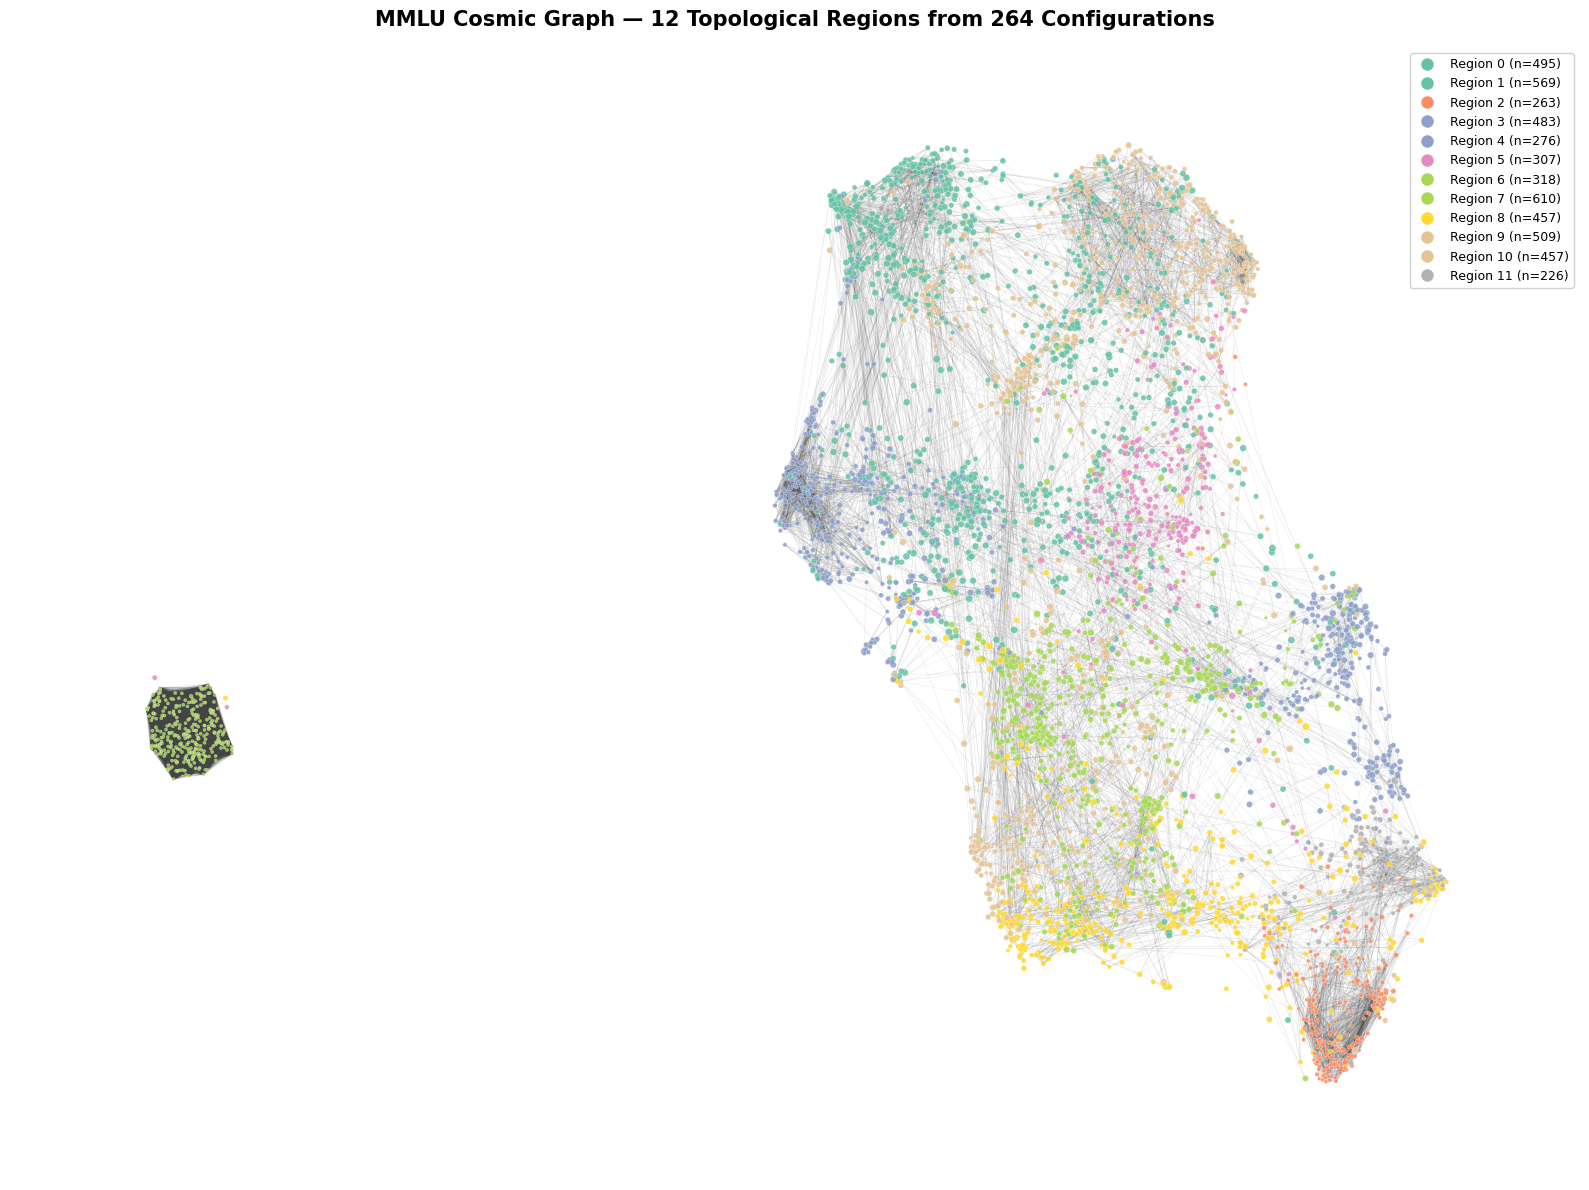

Saved: data/cosmic_graph.png


In [17]:
# UMAP on the subsample for node positions
UMAP_SUB_CACHE = DATA_DIR / "mmlu_umap_sub.npy"

if UMAP_SUB_CACHE.exists():
    umap_sub = np.load(UMAP_SUB_CACHE)
else:
    print("Computing UMAP on subsample...")
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="cosine", random_state=42)
    umap_sub = reducer.fit_transform(embeddings_sub)
    np.save(UMAP_SUB_CACHE, umap_sub)

# Use UMAP coordinates as node positions (avoids spring_layout hairball)
pos = {i: (umap_sub[i, 0], umap_sub[i, 1]) for i in range(len(umap_sub))}

# Build a visualization-only subgraph: keep only edges above the 99th percentile
# weight. The full graph (threshold=0.0) has ~12M edges — drawing all of them
# creates an invisible gray wash. This skeleton shows the strongest structural
# relationships without affecting the spectral clustering (which uses all weights).
W = model.weighted_adjacency
upper = W[np.triu_indices(W.shape[0], k=1)]
nonzero = upper[upper > 0]
viz_threshold = np.percentile(nonzero, 98.5)

viz_edges = []
for u, v, d in G.edges(data=True):
    if d["weight"] >= viz_threshold:
        viz_edges.append((u, v, d["weight"]))

print(f"Visualization threshold: {viz_threshold:.4f} (99th percentile)")
print(f"Drawing {len(viz_edges):,} edges (top 1% by weight)")

# Node properties
degrees = np.array([G.degree(n) for n in range(len(umap_sub))])
node_sizes = 3 + 25 * (degrees / max(degrees.max(), 1))

# Color palette
cmap = plt.cm.Set2
cluster_colors = [cmap(labels[n] / N_CLUSTERS) for n in range(len(umap_sub))]

fig, ax = plt.subplots(figsize=(16, 12), facecolor="white")

# Draw edges first (underneath)
if viz_edges:
    edge_list = [(u, v) for u, v, w in viz_edges]
    edge_w = [w for u, v, w in viz_edges]
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edge_list,
        ax=ax,
        width=[
            0.3 + 2.0 * (w - viz_threshold) / (1.0 - viz_threshold + 1e-9)
            for w in edge_w
        ],
        alpha=0.12,
        edge_color="#444444",
    )

# Draw nodes on top
nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    nodelist=list(range(len(umap_sub))),
    node_size=node_sizes,
    node_color=cluster_colors,
    edgecolors="white",
    linewidths=0.2,
    alpha=0.85,
)

# Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cmap(i / N_CLUSTERS),
        markersize=10,
        label=f"Region {i} (n={cluster_sizes[i]})",
    )
    for i in range(N_CLUSTERS)
]
ax.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=9,
    framealpha=0.9,
    edgecolor="#cccccc",
)

ax.set_title(
    f"MMLU Cosmic Graph \u2014 {N_CLUSTERS} Topological Regions from {n_maps} Configurations",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    DATA_DIR / "cosmic_graph.png", dpi=200, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved: data/cosmic_graph.png")

---
## Step 8: Topology vs. Subject Labels

Main comparison on our **5,000-question stratified subsample**:
- **Left**: colored by Pulsar's topological clusters
- **Right**: colored by **all 57** MMLU subject labels

The all-subject panel includes a **partial legend**: the most frequent subjects are listed explicitly, while the remainder are grouped into a catch-all entry so the figure stays readable.

A second, simplified figure is rendered below using the top 12 subjects plus gray for the remainder.

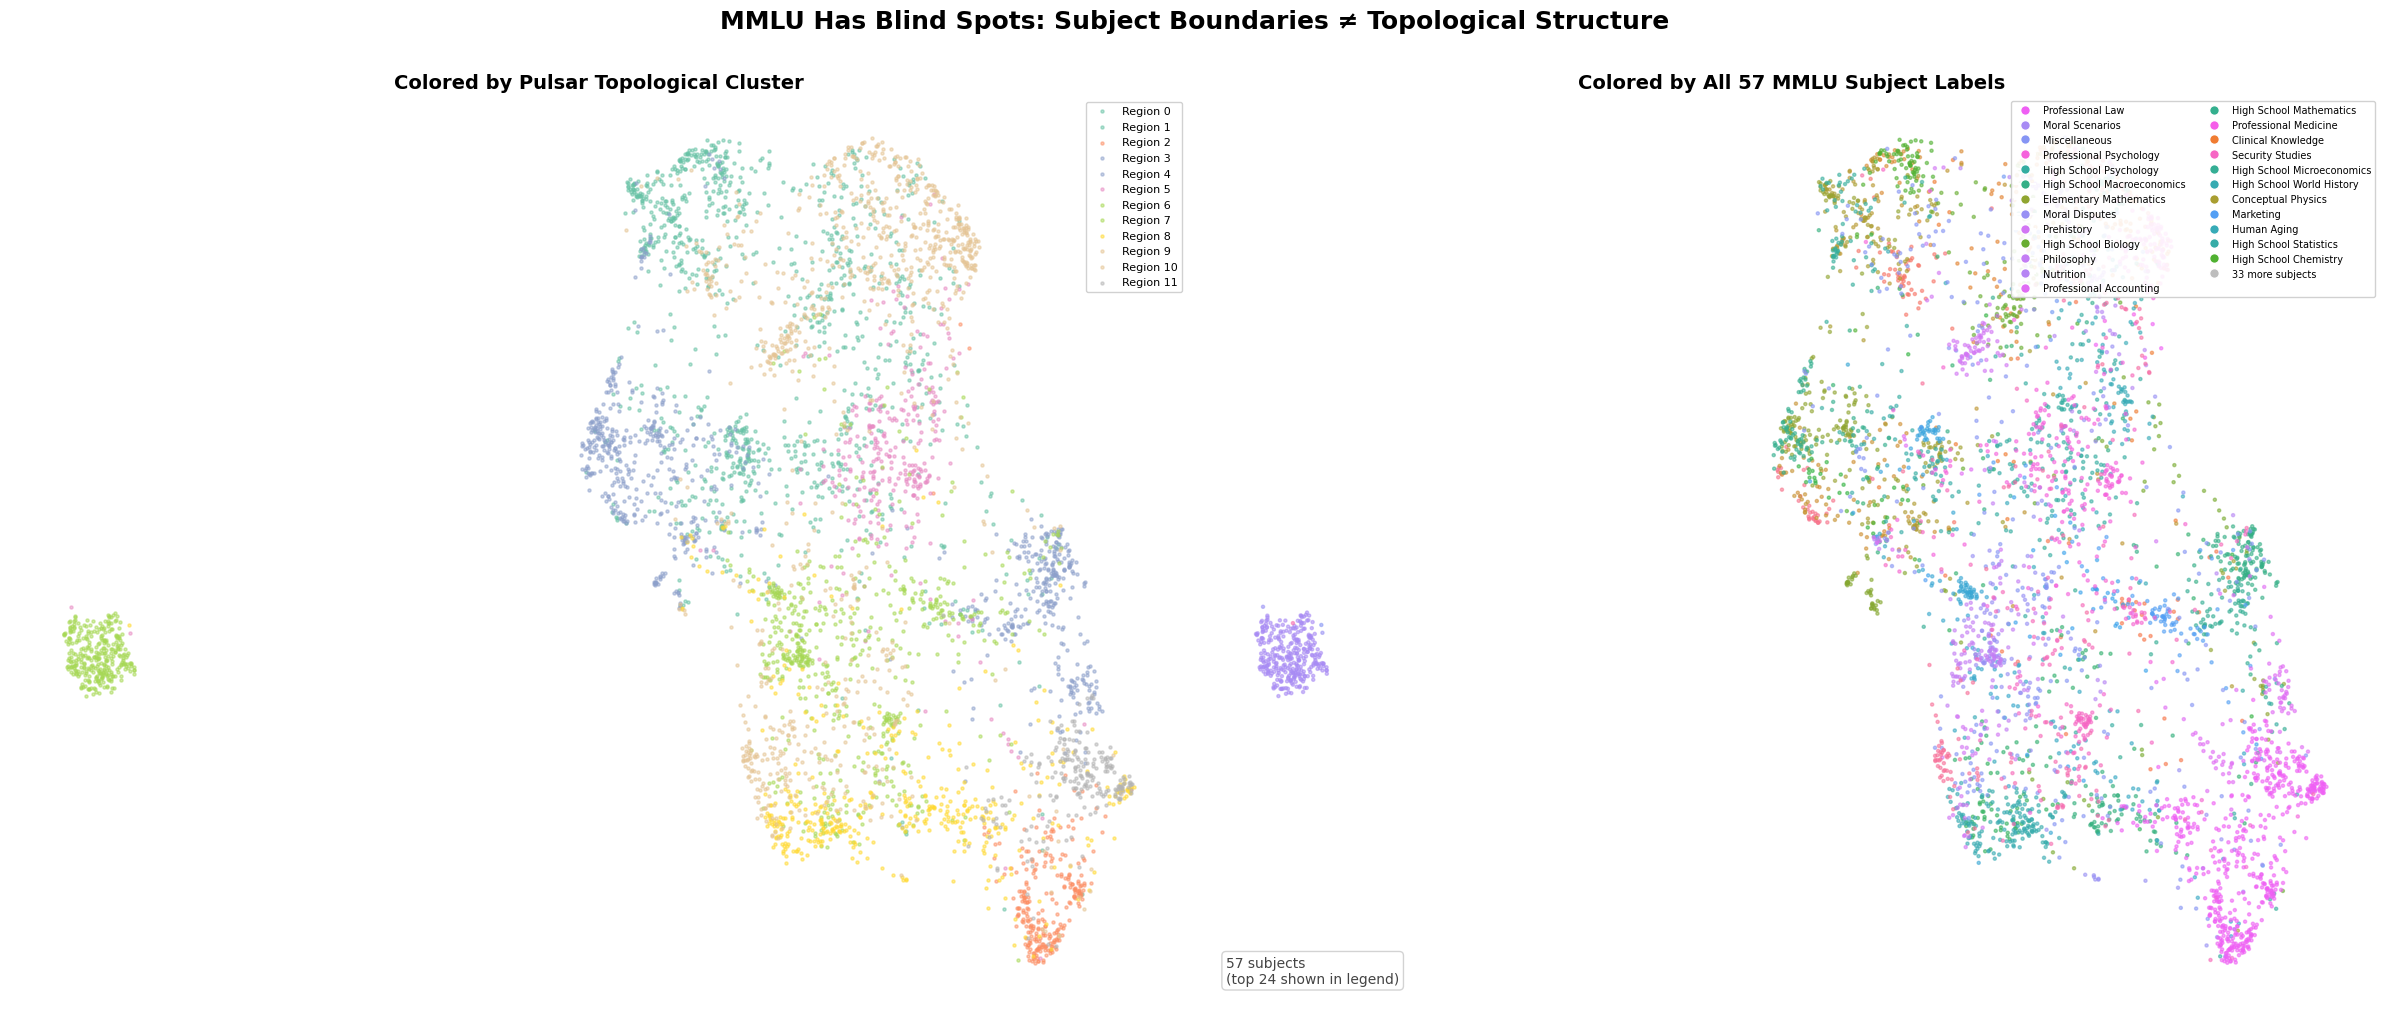

Saved: data/mmlu_hero.png


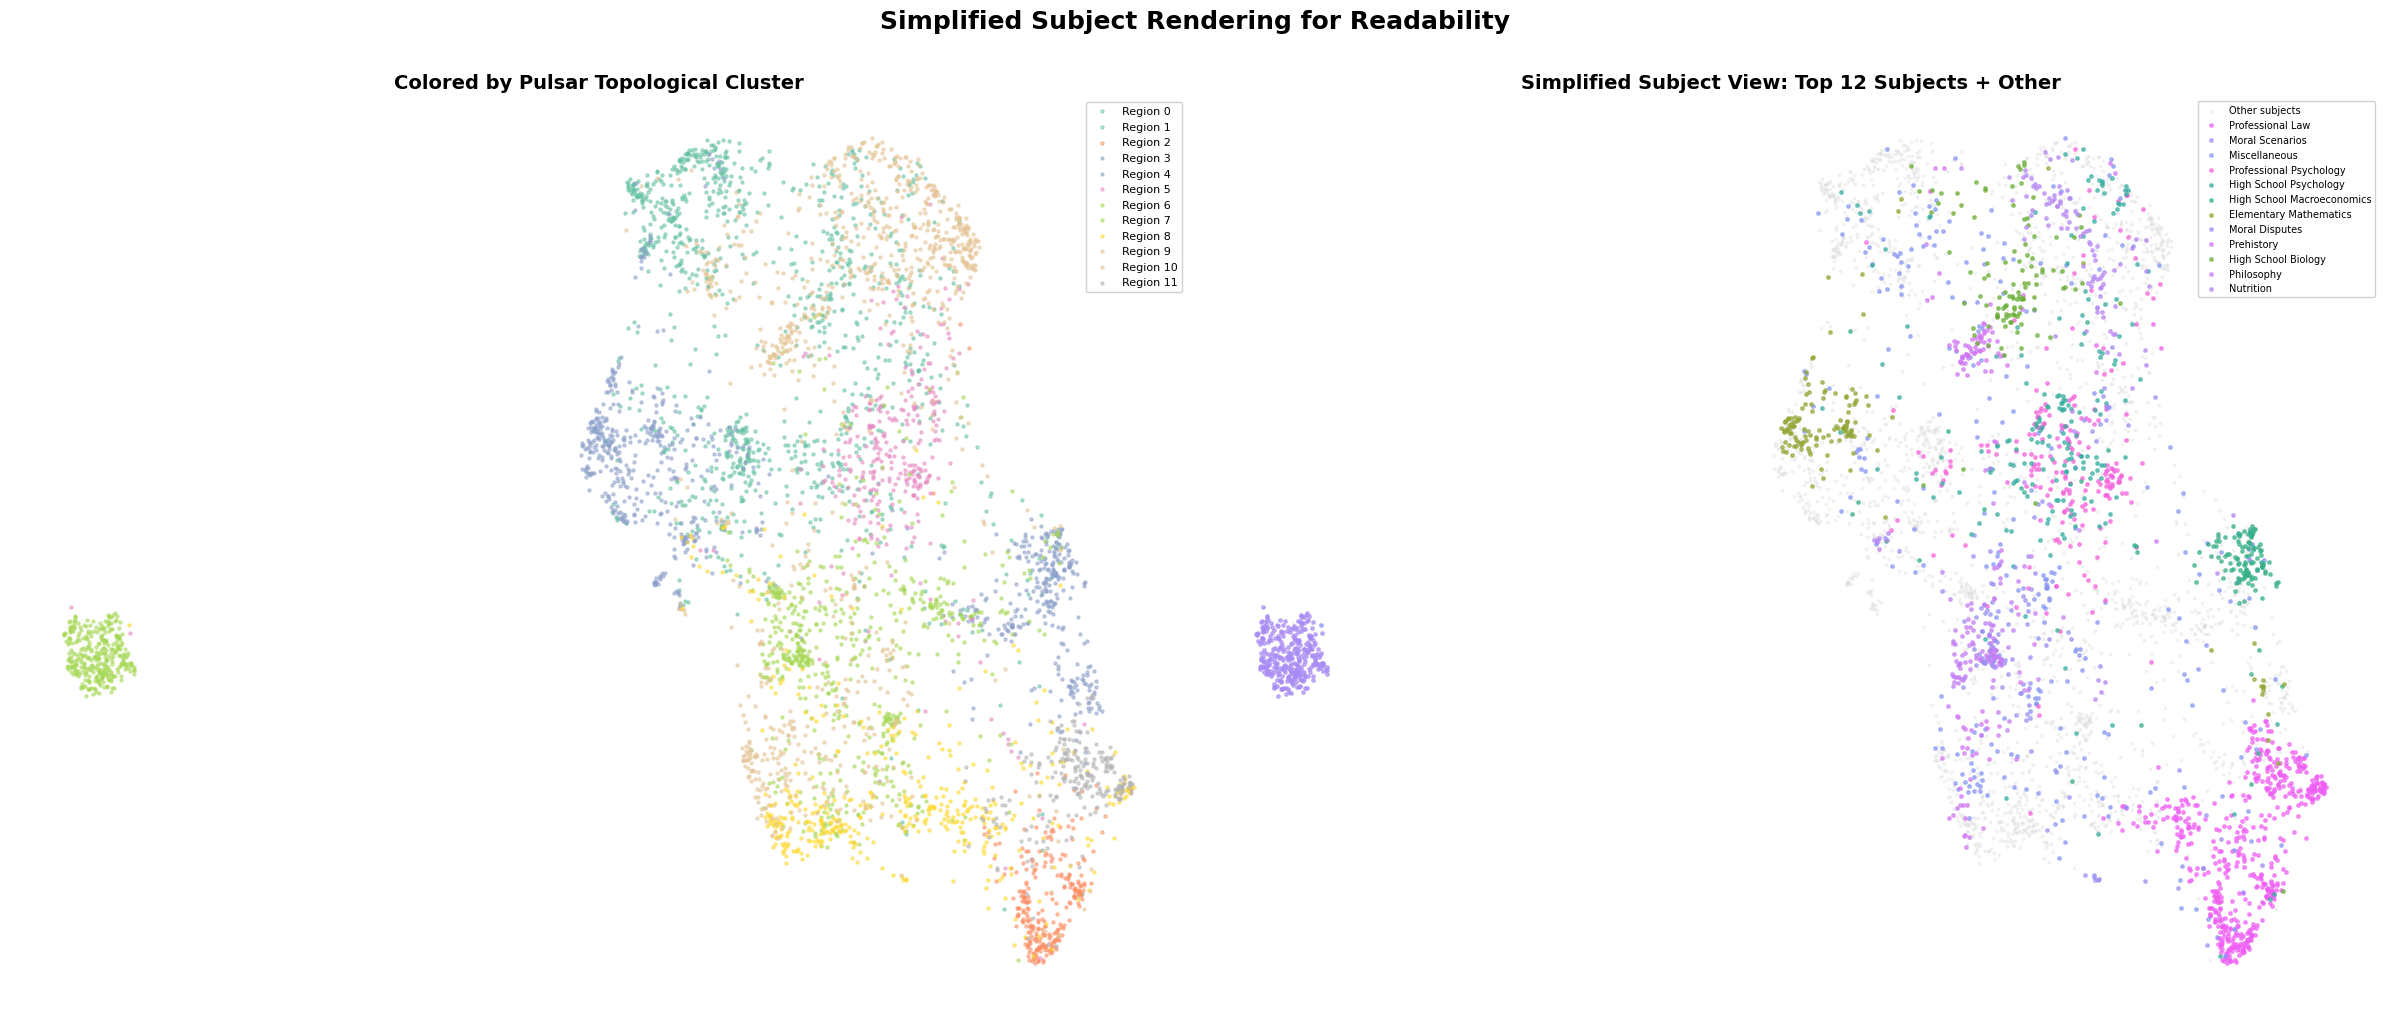

Saved: data/mmlu_hero_simplified.png


In [18]:
# Two-panel hero figure using the 5k subsample
# (5,000 points is visually saturated on a scatterplot — no need to propagate to 14k)
all_subjects = sorted(df_sub["subject"].unique())
subject_palette = sns.color_palette("husl", len(all_subjects))
subject_to_color = {subj: subject_palette[i] for i, subj in enumerate(all_subjects)}
subject_colors = [subject_to_color[subj] for subj in df_sub["subject"]]
top_subjects = df_sub["subject"].value_counts().head(12).index.tolist()
legend_subjects = df_sub["subject"].value_counts().head(24).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(24, 10), facecolor="white")

# LEFT: Pulsar topological clusters
ax = axes[0]
for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(
        umap_sub[mask, 0],
        umap_sub[mask, 1],
        c=[cmap(c / N_CLUSTERS)],
        s=5,
        alpha=0.5,
        rasterized=True,
        label=f"Region {c}",
    )
ax.set_title("Colored by Pulsar Topological Cluster", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax.axis("off")

# RIGHT: all 57 MMLU subjects, with a capped legend for readability
ax = axes[1]
ax.scatter(
    umap_sub[:, 0],
    umap_sub[:, 1],
    c=subject_colors,
    s=5,
    alpha=0.55,
    rasterized=True,
)
ax.set_title("Colored by All 57 MMLU Subject Labels", fontsize=14, fontweight="bold")
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=subject_to_color[subj],
        markersize=7,
        label=subj.replace("_", " ").title(),
    )
    for subj in legend_subjects
]
remaining_subjects = len(all_subjects) - len(legend_subjects)
if remaining_subjects > 0:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="#bdbdbd",
            markersize=7,
            label=f"{remaining_subjects} more subjects",
        )
    )
ax.legend(handles=legend_handles, fontsize=7, loc="upper right", framealpha=0.9, ncol=2)
ax.text(
    0.02,
    0.02,
    f"57 subjects\n(top {len(legend_subjects)} shown in legend)",
    transform=ax.transAxes,
    fontsize=10,
    color="#444444",
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="#cccccc"
    ),
)
ax.axis("off")

fig.suptitle(
    "MMLU Has Blind Spots: Subject Boundaries \u2260 Topological Structure",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "mmlu_hero.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: data/mmlu_hero.png")

# Simplified rendering: top 12 subjects, remainder in gray
fig, axes = plt.subplots(1, 2, figsize=(24, 10), facecolor="white")

ax = axes[0]
for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(
        umap_sub[mask, 0],
        umap_sub[mask, 1],
        c=[cmap(c / N_CLUSTERS)],
        s=5,
        alpha=0.5,
        rasterized=True,
        label=f"Region {c}",
    )
ax.set_title("Colored by Pulsar Topological Cluster", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax.axis("off")

ax = axes[1]
other_mask = ~df_sub["subject"].isin(top_subjects)
ax.scatter(
    umap_sub[other_mask, 0],
    umap_sub[other_mask, 1],
    c="#dddddd",
    s=3,
    alpha=0.3,
    rasterized=True,
    label="Other subjects",
)
for subj in top_subjects:
    mask = (df_sub["subject"] == subj).values
    ax.scatter(
        umap_sub[mask, 0],
        umap_sub[mask, 1],
        c=[subject_to_color[subj]],
        s=6,
        alpha=0.65,
        rasterized=True,
        label=subj.replace("_", " ").title(),
    )
ax.set_title(
    "Simplified Subject View: Top 12 Subjects + Other", fontsize=14, fontweight="bold"
)
ax.legend(fontsize=7, loc="upper right", framealpha=0.9, ncol=1)
ax.axis("off")

fig.suptitle(
    "Simplified Subject Rendering for Readability",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(
    DATA_DIR / "mmlu_hero_simplified.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print("Saved: data/mmlu_hero_simplified.png")

### Reading the Hero Image

The main hero figure compares topology to **all 57 subject labels**. Its legend is capped to the most frequent subjects, with the remainder grouped together so the figure stays readable. The simplified figure below it keeps only the 12 most frequent subjects colored so the label story remains readable.

Compare the two panels in the main figure:

**Left (topology):** Clean, contiguous regions. Pulsar's spectral clustering finds coherent geometric communities in the cosmic graph — groups of questions that consistently co-occur in the same topological neighborhoods across 264 parameter configurations.

**Right (all subjects):** Scattered, overlapping colors. MMLU's 57 subject labels don't map onto the geometric structure. Multiple subjects occupy the same spatial region, and individual subjects fragment across the map.

**Simplified subject view:** The top 12 subjects are easier to track visually, but the fragmentation story is the same. The simplified rendering is for readability; the all-57 panel is the honest comparison.

The mismatch is the point. When a leaderboard reports "Model X scores 78% on MMLU," it's averaging across regions that have fundamentally different geometric properties. A model could score 90% in the dense law cluster and 60% in the diffuse math/physics region, and the headline number hides both.

---
## Step 9: Per-Region Model Accuracy

The heatmap below uses **all completed model runs currently available** in `data/model_eval_results.csv`.

That file is built from finalized per-model outputs in `data/eval_results/`, so the figure updates as new runs finish. If legacy or open-source model results are present on disk, they will appear automatically.

Each question is scored correct/incorrect, then grouped by topological region. This is **per-question** accuracy — not averaged from subject-level scores — eliminating any ecological inference.

If all regions were equally difficult, every column in the heatmap would be uniform. They aren't.

/var/folders/k7/0rzr3dqs285dr7xdltk5w6340000gn/T/ipykernel_94650/2598221215.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


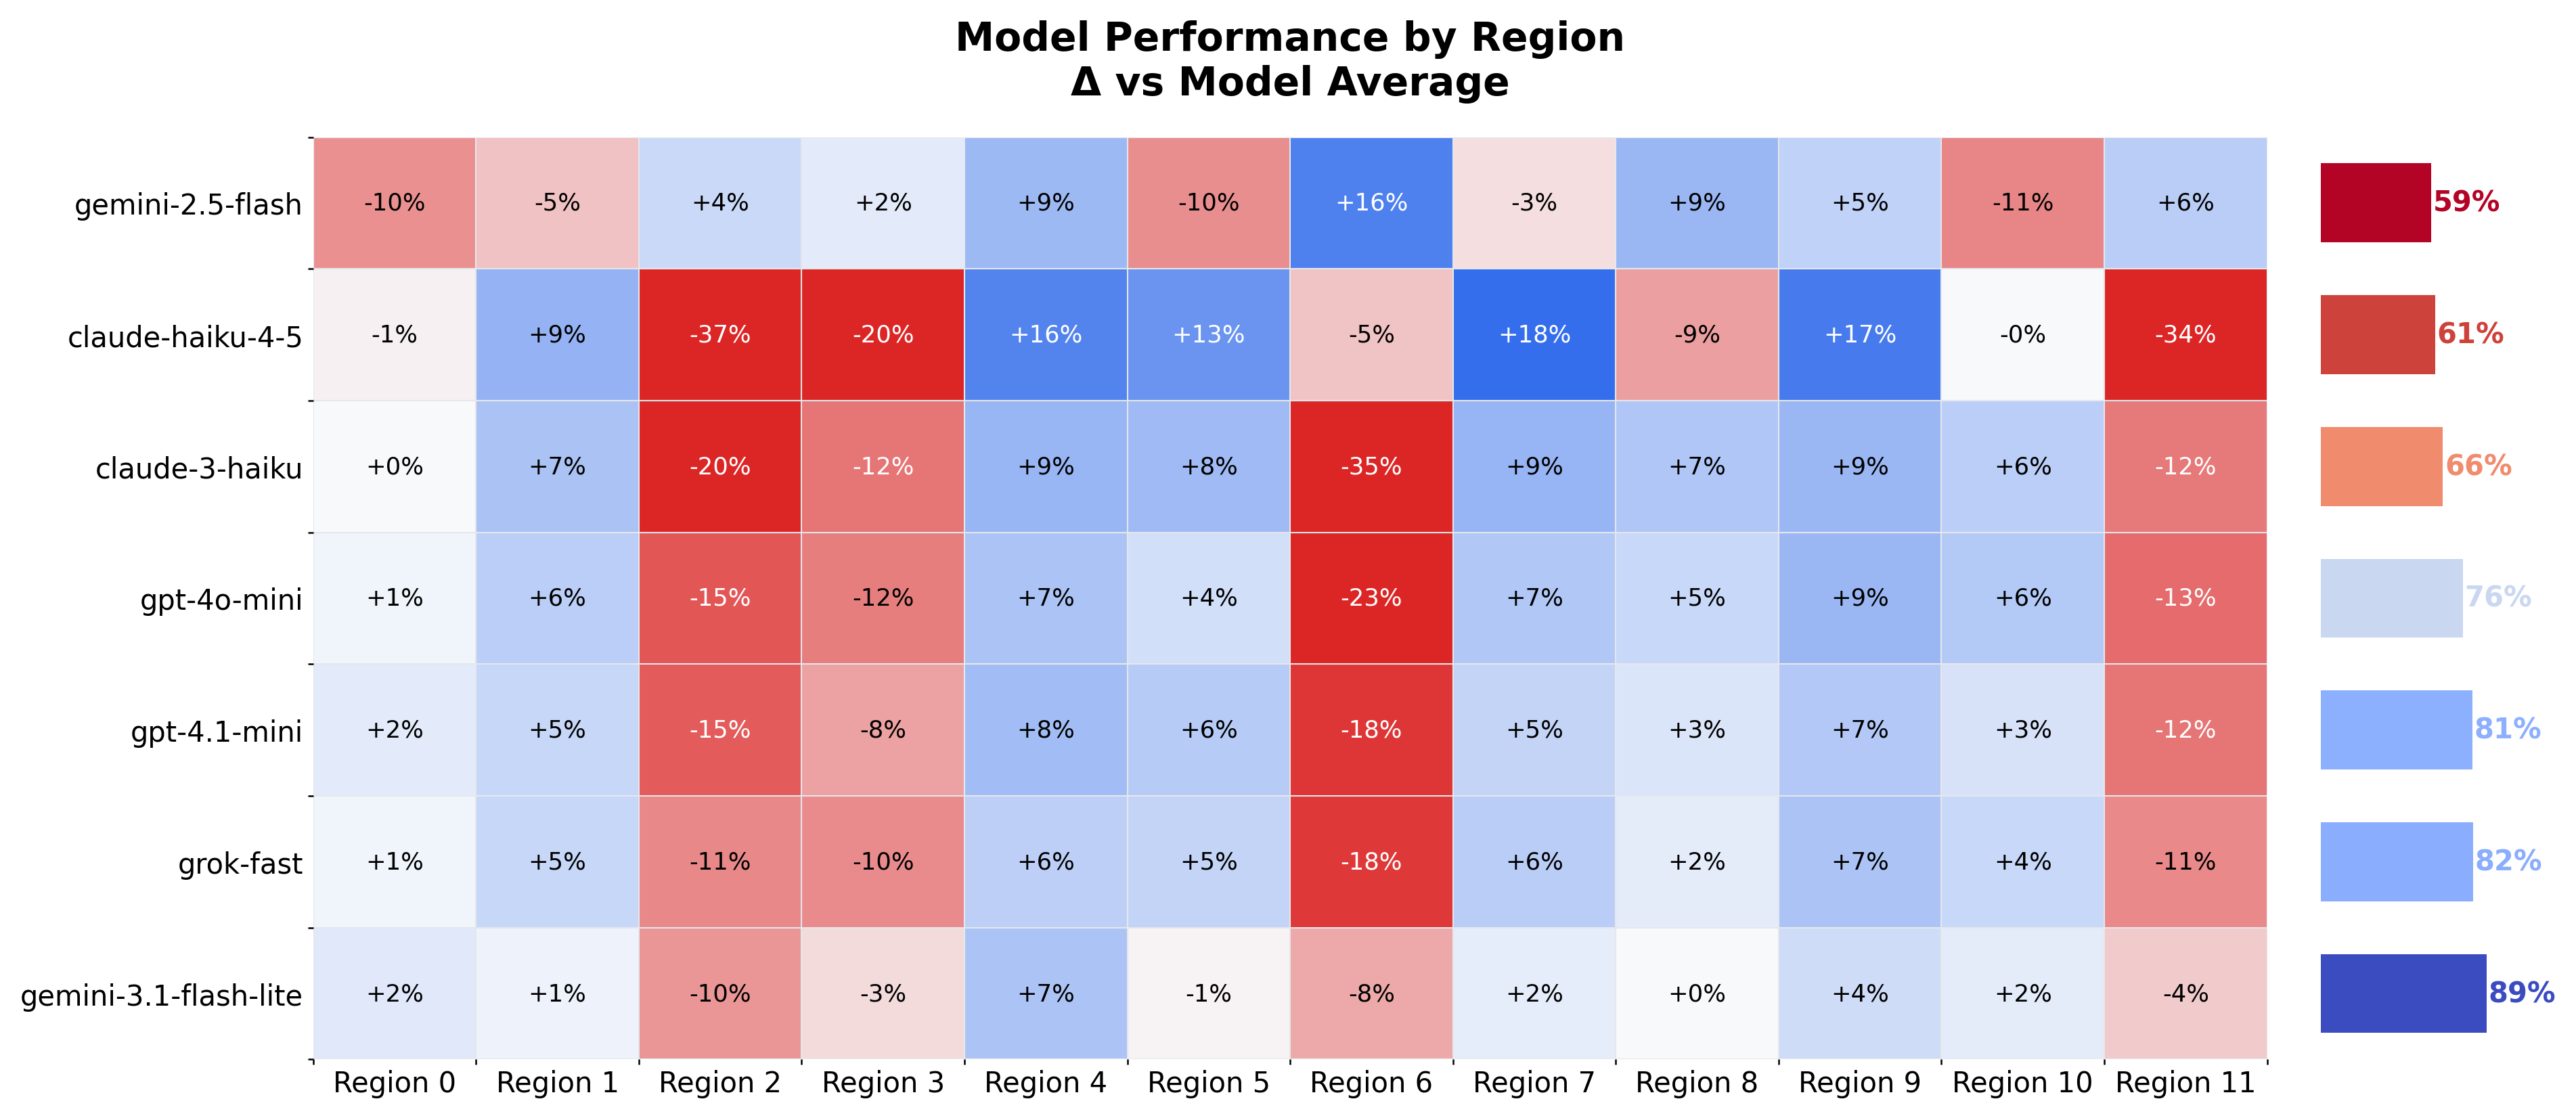

In [11]:
# =========================
# Clean Heatmap (Final Polished)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# --- Load + merge ---
eval_df = pd.read_csv(DATA_DIR / "model_eval_results.csv")

eval_df = eval_df.merge(
    df_sub[["cluster"]].reset_index().rename(columns={"index": "question_index"}),
    on="question_index",
)

cluster_perf = (
    eval_df.groupby(["model_name", "cluster"])["is_correct"].mean().reset_index()
)

pivot = cluster_perf.pivot(index="model_name", columns="cluster", values="is_correct")
pivot = pivot.reindex(columns=range(N_CLUSTERS))

# Overall accuracy
overall = (
    eval_df.groupby("model_name")["is_correct"].mean().sort_values(ascending=False)
)
pivot = pivot.loc[overall.index]

# --- Delta vs model average ---
delta = pivot.sub(overall, axis=0)

model_names = delta.index.tolist()
cluster_values = delta.values

# --- Heatmap colormap ---
diverging_cmap = LinearSegmentedColormap.from_list(
    "clean_diverging",
    ["#dc2626", "#f8fafc", "#2563eb"],  # red → white → blue
)

vmin, vmax = -0.20, 0.20

# --- Bar colors (based on absolute performance) ---
norm = Normalize(vmin=overall.min(), vmax=overall.max())
bar_cmap = plt.get_cmap("coolwarm_r")
bar_colors = bar_cmap(norm(overall.values))

# --- Layout ---
fig = plt.figure(
    figsize=(14, max(4.5, 0.7 * len(model_names) + 1)), facecolor="white", dpi=300
)

gs = fig.add_gridspec(1, 2, width_ratios=[20, 2], wspace=0.05)

ax = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1], sharey=ax)

# --- Heatmap ---
im = ax.imshow(cluster_values, cmap=diverging_cmap, aspect="auto", vmin=vmin, vmax=vmax)

# --- Axis labels ---
ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels([f"Region {i}" for i in range(N_CLUSTERS)], fontsize=10)

# ✅ CLEAN model labels (no accuracy)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=10)

# --- Annotate ALL cells ---
for i in range(len(model_names)):
    for j in range(N_CLUSTERS):
        val = cluster_values[i, j]

        if np.isnan(val):
            text = "–"
            color = "#9ca3af"
        else:
            text = f"{val:+.0%}"
            color = "black" if abs(val) < 0.12 else "white"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="medium",
            color=color,
        )

# --- Grid ---
ax.set_xticks(np.arange(-0.5, N_CLUSTERS, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(model_names), 1), minor=True)
ax.grid(which="minor", color="#e5e7eb", linestyle="-", linewidth=0.5)

# --- Clean frame ---
ax.spines[:].set_visible(False)
ax.tick_params(axis="both", length=0)

# --- Title ---
ax.set_title(
    "Model Performance by Region\nΔ vs Model Average",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

# --- Side bar (colored + annotated) ---
y_pos = np.arange(len(model_names))

ax_bar.barh(y_pos, overall.values, height=0.6, color=bar_colors)

# ✅ Add value labels to bars
for i, val in enumerate(overall.values):
    ax_bar.text(
        val + 0.01,  # slight offset to the right
        i,
        f"{val:.0%}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=bar_colors[i],
    )

ax_bar.set_xlim(0, 1.05)
ax_bar.invert_yaxis()
ax_bar.axis("off")

# --- Save ---
plt.tight_layout()
plt.savefig(DATA_DIR / "model_heatmap_final.png", dpi=220, bbox_inches="tight")
plt.show()

---
## Step 9.5: Topology Blind Spots — Do Subject Baselines Explain Model Failure?

### The Question

When a model fails on a topological region, is it because:

1. **Subject difficulty?** The region contains subjects the model is bad at
2. **Topology itself?** The region is geometrically a blind spot, *even for subjects the model usually handles well*

### How We Test This

For each model and region:

- **Expected Accuracy** (X-axis): What the model *should* score, based on its global performance on the subjects in that region
  - Example: Region 3 has 60% Law + 40% History. Model X is 75% on Law globally, 65% on History globally → Expected: 0.6×75% + 0.4×65% = **71%**

- **Actual Accuracy** (Y-axis): What the model *really* scored on questions in that region
  - Example: Region 3, Model X actually got **58%**

### Reading the Plot

Each dot is one (model, region) pair:

- **On the diagonal line**: Model performs *exactly* as expected (no topology penalty)
- **Below the line** (red zone): Model underperforms. Topology is a blind spot.
- **Above the line** (blue zone): Model overperforms. Topology is a strength.

### Dot Size & Brightness

- **Large, bright dots**: |Δ| > 2.5% — real blind spots worth investigating
- **Small, faint dots**: |Δ| ≤ 2.5% — within noise, no meaningful topology penalty

### What This Proves

If all dots cluster on the diagonal, it means: **Models perform exactly as expected based on subject difficulty.** Topology doesn't add blind spots — regions are just mixtures of subjects.

If dots scatter *below* the line (especially large ones), it means: **Topology is creating blind spots beyond what subject difficulty predicts.** The geometric structure of MMLU is causing failure.

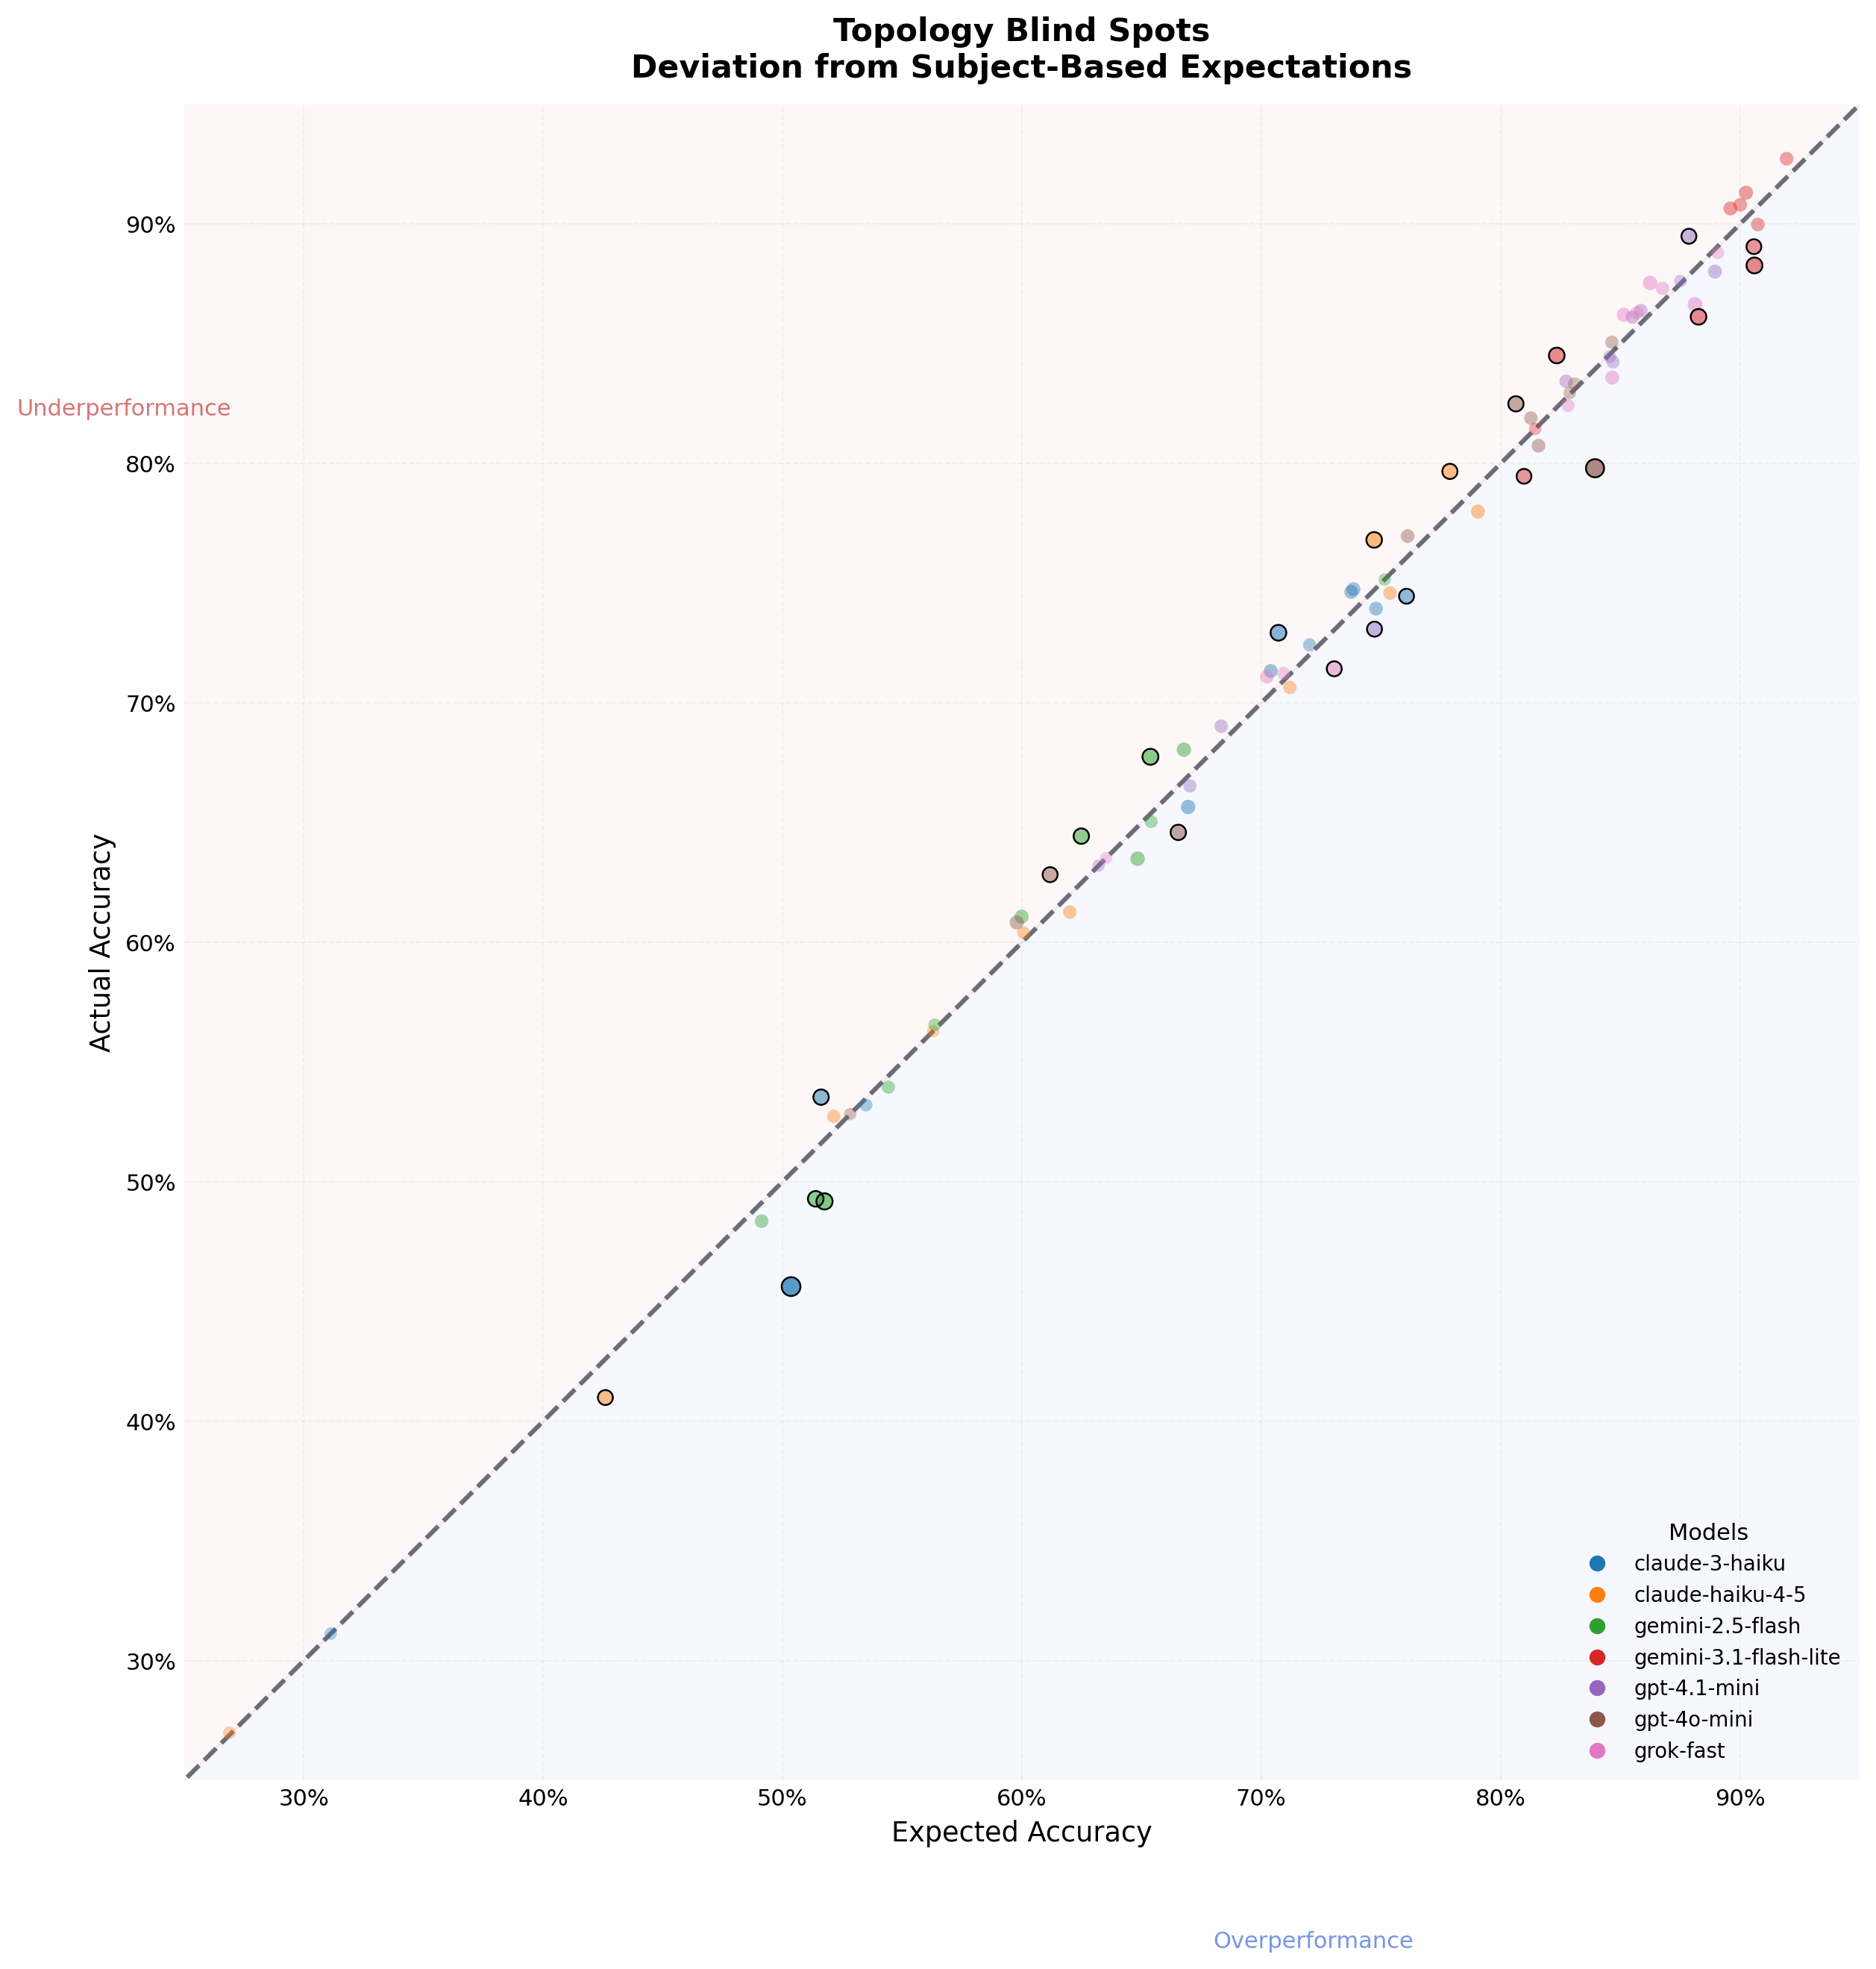


TOPOLOGY BLIND SPOTS (|Δ| > 1.5%)

claude-3-haiku:
  Region  2: -4.7% (expected 50.4%, got 45.6%)
  Region  9: -1.6% (expected 76.1%, got 74.5%)
  Region 11: +1.9% (expected 51.6%, got 53.5%)
  Region  1: +2.2% (expected 70.7%, got 72.9%)

claude-haiku-4-5:
  Region  3: -1.6% (expected 42.6%, got 41.0%)
  Region  7: +1.8% (expected 77.9%, got 79.7%)
  Region  4: +2.1% (expected 74.7%, got 76.8%)

gemini-2.5-flash:
  Region  5: -2.6% (expected 51.8%, got 49.2%)
  Region  0: -2.1% (expected 51.4%, got 49.3%)
  Region  9: +2.0% (expected 62.5%, got 64.4%)
  Region  4: +2.4% (expected 65.4%, got 67.8%)

gemini-3.1-flash-lite:
  Region  5: -2.3% (expected 90.6%, got 88.3%)
  Region  3: -2.1% (expected 88.3%, got 86.1%)
  Region  8: -1.5% (expected 90.6%, got 89.1%)
  Region  2: -1.5% (expected 81.0%, got 79.5%)
  Region 11: +2.2% (expected 82.3%, got 84.5%)
  Region  4: +3.1% (expected 92.9%, got 96.0%)

gpt-4.1-mini:
  Region  3: -1.6% (expected 74.7%, got 73.1%)
  Region  4: +1.6% (expec

In [12]:
# =========================
# Topology Blind Spots — Clean Scatter (Outlined Significant Points)
# =========================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Data prep ---
# Re-read raw CSV so this cell is idempotent when re-run standalone
eval_df = pd.read_csv(DATA_DIR / "model_eval_results.csv")
eval_df = eval_df.merge(
    df_sub[["cluster"]].reset_index().rename(columns={"index": "question_index"}),
    on="question_index",
)
eval_df = eval_df.merge(
    df_sub[["subject"]].reset_index().rename(columns={"index": "question_index"}),
    on="question_index",
    how="left",
)

subject_accuracy = (
    eval_df.groupby(["model_name", "subject"])["is_correct"]
    .mean()
    .reset_index()
    .rename(columns={"is_correct": "subject_acc"})
)

cluster_composition = (
    df_sub.reset_index()
    .groupby(["cluster", "subject"])
    .size()
    .reset_index(name="count")
)

cluster_totals = (
    cluster_composition.groupby("cluster")["count"].sum().reset_index(name="total")
)
cluster_composition = cluster_composition.merge(cluster_totals, on="cluster")
cluster_composition["proportion"] = (
    cluster_composition["count"] / cluster_composition["total"]
)

expected_df = cluster_composition.merge(subject_accuracy, on="subject", how="left")
expected_df["weighted_acc"] = expected_df["proportion"] * expected_df["subject_acc"]

expected_accuracy = (
    expected_df.groupby(["model_name", "cluster"])["weighted_acc"]
    .sum()
    .reset_index()
    .rename(columns={"weighted_acc": "expected_acc"})
)

actual_accuracy = (
    eval_df.groupby(["model_name", "cluster"])["is_correct"]
    .mean()
    .reset_index()
    .rename(columns={"is_correct": "actual_acc"})
)

scatter_df = actual_accuracy.merge(expected_accuracy, on=["model_name", "cluster"])
scatter_df["delta"] = scatter_df["actual_acc"] - scatter_df["expected_acc"]
scatter_df["abs_delta"] = np.abs(scatter_df["delta"])

# --- VISUAL DESIGN STARTS HERE ---

fig, ax = plt.subplots(figsize=(12, 12), dpi=220, facecolor="white")

models = sorted(scatter_df["model_name"].unique())

# Clean palette
base_colors = mpl.colormaps["tab10"]
model_colors = {m: base_colors(i) for i, m in enumerate(models)}


# --- Scaling functions ---
def size_scale(d):
    return 30 + (d * 800)


def alpha_scale(d):
    return (0.35 + (d * 8)).clip(upper=0.85)


# --- Plot points (BASE LAYER: no edges) ---
for m in models:
    df_m = scatter_df[scatter_df["model_name"] == m]

    ax.scatter(
        df_m["expected_acc"],
        df_m["actual_acc"],
        s=size_scale(df_m["abs_delta"]),
        alpha=alpha_scale(df_m["abs_delta"]),
        color=model_colors[m],
        edgecolors="none",
        zorder=5,
    )

# --- OVERLAY: outlined significant deviations (>1.5%) ---
sig = scatter_df[scatter_df["abs_delta"] > 0.015]

ax.scatter(
    sig["expected_acc"],
    sig["actual_acc"],
    s=size_scale(sig["abs_delta"]),
    facecolors="none",
    edgecolors="black",
    linewidth=0.8,
    zorder=10,
)

# --- Diagonal ---
ax.plot([0, 1], [0, 1], linestyle="--", color="#111827", linewidth=2, alpha=0.6)

# --- Subtle region shading ---
x = np.linspace(0, 1, 100)

ax.fill_between(x, x, 1, color="#ef4444", alpha=0.04)
ax.fill_between(x, x, 0, color="#2563eb", alpha=0.04)

# --- Labels ---
ax.text(0.18, 0.82, "Underperformance", fontsize=10, color="#b91c1c", alpha=0.6)
ax.text(0.68, 0.18, "Overperformance", fontsize=10, color="#1d4ed8", alpha=0.6)

# --- Axes ---
ax.set_xlim(0.25, 0.95)
ax.set_ylim(0.25, 0.95)
ax.set_aspect("equal")

ax.set_xlabel("Expected Accuracy", fontsize=12)
ax.set_ylabel("Actual Accuracy", fontsize=12)

ax.set_title(
    "Topology Blind Spots\nDeviation from Subject-Based Expectations",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

# Percent formatting
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))

# Grid
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.15)

# Clean frame
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

# Legend
handles = [
    mpl.lines.Line2D(
        [0], [0], marker="o", linestyle="", color=model_colors[m], label=m, markersize=6
    )
    for m in models
]

ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=9, title="Models")

# --- Save ---
plt.tight_layout()
plt.savefig(DATA_DIR / "topology_blind_spots_clean.png", dpi=220, bbox_inches="tight")
plt.show()

# Summary: Focus on points with > 2.5% delta
print("\n" + "=" * 70)
print("TOPOLOGY BLIND SPOTS (|Δ| > 1.5%)")
print("=" * 70 + "\n")
significant = scatter_df[scatter_df["abs_delta"] > 0.015]
if len(significant) > 0:
    for m in models:
        model_sig = significant[significant["model_name"] == m].sort_values("delta")
        if len(model_sig) > 0:
            print(f"{m}:")
            for _, row in model_sig.iterrows():
                print(
                    f"  Region {int(row['cluster']):2d}: {row['delta']:+.1%} (expected {row['expected_acc']:.1%}, got {row['actual_acc']:.1%})"
                )
            print()
else:
    print("No regions with > 1.5% difference found.")

---
## Step 10: What Random Sampling Misses

If you randomly sample MMLU questions for evaluation, how many do you need to **cover all topological regions**? Small or structurally unique regions get systematically under-sampled.

Pulsar's topology-aware approach identifies all regions by construction.

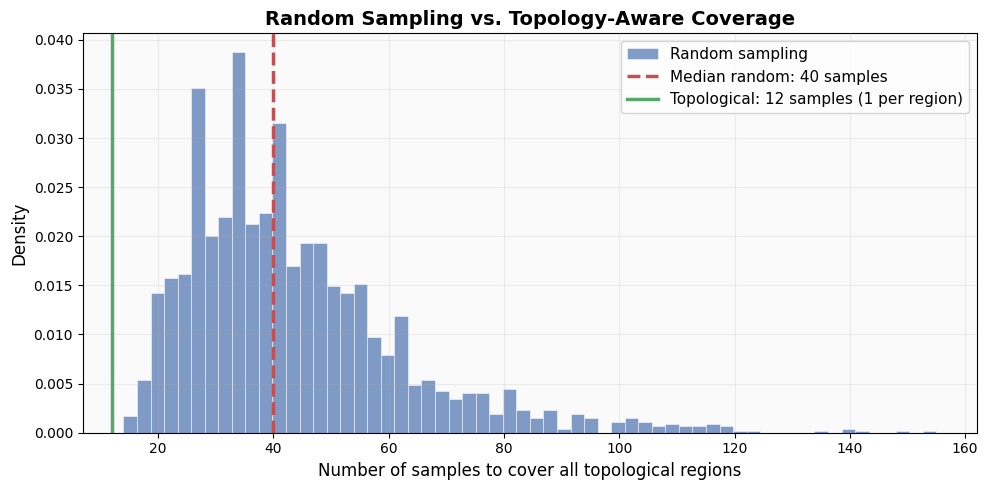

Smallest topological region: 226 questions (4.5% of sample)
Random sampling needs a median of 40 draws to see all 12 regions
95th percentile: 82 draws
Topology-aware sampling needs exactly 12 (one per region)

Random sampling needs ~3x more questions to achieve the same structural coverage.


In [13]:
def random_coverage_trials(cluster_labels, n_trials=2000):
    """For each trial, count how many random draws until all clusters are seen."""
    K = len(np.unique(cluster_labels))
    n = len(cluster_labels)
    rng = np.random.default_rng(42)
    counts = []
    for _ in range(n_trials):
        seen = set()
        for i, idx in enumerate(rng.permutation(n), 1):
            seen.add(cluster_labels[idx])
            if len(seen) == K:
                counts.append(i)
                break
    return np.array(counts)


coverage_counts = random_coverage_trials(labels)

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

ax.hist(
    coverage_counts,
    bins=60,
    density=True,
    alpha=0.7,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    label="Random sampling",
)

median_random = np.median(coverage_counts)
ax.axvline(
    median_random,
    color="#C44E52",
    linestyle="--",
    linewidth=2.5,
    label=f"Median random: {median_random:.0f} samples",
)

ax.axvline(
    N_CLUSTERS,
    color="#55A868",
    linestyle="-",
    linewidth=2.5,
    label=f"Topological: {N_CLUSTERS} samples (1 per region)",
)

ax.set_xlabel("Number of samples to cover all topological regions", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(
    "Random Sampling vs. Topology-Aware Coverage", fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.set_facecolor("#fafafa")

plt.tight_layout()
plt.savefig(
    DATA_DIR / "coverage_comparison.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

smallest_cluster = cluster_sizes.min()
smallest_pct = 100 * smallest_cluster / len(labels)
p95 = np.percentile(coverage_counts, 95)

print(
    f"Smallest topological region: {smallest_cluster} questions ({smallest_pct:.1f}% of sample)"
)
print(
    f"Random sampling needs a median of {median_random:.0f} draws to see all {N_CLUSTERS} regions"
)
print(f"95th percentile: {p95:.0f} draws")
print(f"Topology-aware sampling needs exactly {N_CLUSTERS} (one per region)")
print(
    f"\nRandom sampling needs ~{median_random / N_CLUSTERS:.0f}x more questions to achieve "
    f"the same structural coverage."
)

---
## What This Means

**MMLU is not a uniform test.** It has 12 distinct geometric regions — clusters of questions that share structural similarity in embedding space, regardless of their official subject label.

Standard leaderboard reporting collapses all of this into a single number. Even per-subject breakdowns miss the point, because **subjects don't align with the actual geometric structure** of the question space.

### Key findings:

1. Pulsar's 264-configuration topological sweep + silhouette analysis reveals **12 structurally distinct regions** in MMLU — data-driven, zero manual tuning
2. Two subjects form tight geometric islands: `moral_scenarios` (100% isolation, likely a prompt-template artifact) and `professional_law` (87% of its region). These are structurally unlike the rest of the benchmark.
3. Most regions span 30–50+ subjects — the real structure is **thematic** (quantitative reasoning, legal analysis, medical expertise, ethical judgment), not administrative (subject labels)
4. Per-question evaluation across all completed model runs on disk — including legacy or open-source runs if present in `data/eval_results/` — shows **significant accuracy gaps** between best and worst regions, but the leaderboard never shows you this
5. Random evaluation sampling needs **3x more questions** than topology-aware sampling to cover all 12 regions

### Embedding lens caveat:

The geometric structure above is discovered in bge-small-en-v1.5's embedding space. A different embedding model might produce different cluster boundaries. This is a feature: Pulsar can characterize how *any* representation organizes a dataset.

### Smooth data vs. structured data:

MMLU is actually a **hard case** for topological analysis — text embeddings are smooth and concentrated, with no natural gaps. Pulsar's auto-threshold (persistent homology on edge weights) is designed for data with clear separations: clinical records, genomic profiles, sensor data, financial instruments. For that kind of data, the full pipeline works out of the box with zero parameter tuning.

The fact that Pulsar still finds 12 meaningful, interpretable regions in MMLU — via spectral clustering on the cosmic graph with silhouette-driven k selection — means it will find *much more* in data that actually has geometric features to discover.

### What to do about it:

If you're building eval pipelines, curating training data, or doing any unsupervised analysis on text — **you should know what geometric regions your data has before you sample from it.**

Pulsar finds this structure in under a minute.

---

**[Install Pulsar](https://github.com/Krv-Labs/pulsar)** | `uv pip install thema-pulsar`